In [3]:
import cell2fate as c2f
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
#data_name = 'Pancreas_with_cc'

/home/zhangyufeng/miniconda3/envs/scarches/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
Global seed set to 0


In [6]:
results_path = "../../result/cell2fate/"
data_name = "E125_1"

In [7]:
E12_1= sc.read_loom("../../../2024.4_scATAC/data/rna/E12.5_K5mTmG_1.loom")
E12_2= sc.read_loom("../../../2024.4_scATAC/data/rna/E12.5_K5mTmG_2.loom")
E14_1= sc.read_loom("../../../2024.4_scATAC/data/rna/E14.5_K5mTmG_1.loom")
E14_2= sc.read_loom("../../../2024.4_scATAC/data/rna/E14.5_K5mTmG_2.loom")
adata_bk = sc.read("../../../2024.4_scATAC/processed_data/framework/4.29_scvi.h5ad")
newumap=pd.read_csv("../../../2024.4_scATAC/processed_data/embedding/RNA_scvi_umap.csv",index_col=0)
adata_bk.obsm["X_umap"] = np.array(newumap)
drawgraph_emb = pd.read_csv("../../../2024.4_scATAC/processed_data/embedding/RNA_scvi_20neibor_drawgraph.csv",index_col=0)
adata_bk.obsm["X_draw_graph"] = np.array(drawgraph_emb)
scvi = pd.read_csv("../../../2024.4_scATAC/processed_data/embedding/RNA_scvi_latent.csv",index_col=0)
adata_bk.obsm["X_scvi"] = np.array(scvi)

In [9]:
adata =adata_bk

In [11]:
def reverse_transform(input_str):
    parts = input_str.split('_')
    sequence = parts[2].split('-')[0]
    new_string = f"{parts[0]}_K5_mTmG_{parts[1]}:{sequence}x"
    return new_string


def reverse_transform2(input_str):
    parts = input_str.split('_')
    sequence = parts[2].split('-')[0]
    new_string = f"K5mTmG_{parts[1]}:{sequence}x"
    return new_string
newnames = [reverse_transform(s) for s in adata.obs_names]
newnamesE14 = [reverse_transform2(s) for s in adata.obs_names]
E12_1.var_names_make_unique()
E12_2.var_names_make_unique()
E14_1.var_names_make_unique()
E14_2.var_names_make_unique()
E12_1 = E12_1[np.intersect1d(newnames,E12_1.obs_names)].copy()
E12_2 = E12_2[np.intersect1d(newnames,E12_2.obs_names)].copy()
E14_1 = E14_1[np.intersect1d(newnamesE14,E14_1.obs_names)].copy()
E14_2 = E14_2[np.intersect1d(newnamesE14,E14_2.obs_names)].copy()
def get_indices(lst, search_lst):
    indices = []
    for item in search_lst:
        try:
            index = lst.index(item)
            indices.append(index)
        except ValueError:
            pass
    return indices
result1 = get_indices(newnames, E12_1.obs_names)
result2 = get_indices(newnames, E12_2.obs_names)
result3 = get_indices(newnamesE14, E14_1.obs_names)
result4 = get_indices(newnamesE14, E14_2.obs_names)
E12_1.obsm["X_draw_graph"] = adata.obsm["X_draw_graph"][result1]
E12_2.obsm["X_draw_graph"] = adata.obsm["X_draw_graph"][result2]
E14_1.obsm["X_draw_graph"] = adata.obsm["X_draw_graph"][result3]
E14_2.obsm["X_draw_graph"] = adata.obsm["X_draw_graph"][result4]



E12_1.obsm["X_umap"] = adata.obsm["X_umap"][result1]
E12_2.obsm["X_umap"] = adata.obsm["X_umap"][result2]
E14_1.obsm["X_umap"] = adata.obsm["X_umap"][result3]
E14_2.obsm["X_umap"] = adata.obsm["X_umap"][result4]
annotation = pd.read_csv("../../../2024.4_scATAC/processed_data/cluster/rna_annotation_scvi_mod.csv",index_col=0)
E12_1.obs["level1_anno"] = np.array(annotation["level1_anno"][result1])
E12_2.obs["level1_anno"] = np.array(annotation["level1_anno"][result2])
E14_1.obs["level1_anno"] = np.array(annotation["level1_anno"][result3])
E14_2.obs["level1_anno"] = np.array(annotation["level1_anno"][result4])


In [12]:
clusters_to_remove = []
adata =  c2f.utils.get_training_data(E12_1, cells_per_cluster = 10**5, cluster_column = 'level1_anno',
                                    remove_clusters = clusters_to_remove,
                                min_shared_counts = 20, n_var_genes= 3000)

Keeping at most 100000 cells per cluster
Filtered out 22805 genes that are detected 20 counts (shared).
Extracted 3000 highly variable genes.


<AxesSubplot:title={'center':'level1_anno'}, xlabel='UMAP1', ylabel='UMAP2'>

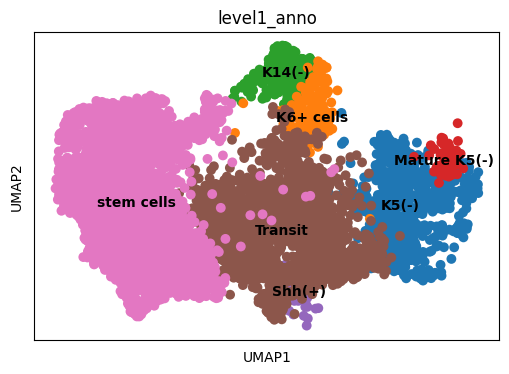

In [13]:
fig, ax = plt.subplots(1,1, figsize = (6, 4))
sc.pl.umap(adata, color = ['level1_anno'], s = 200, legend_loc='on data', show = False, ax = ax)

In [14]:
c2f.Cell2fate_DynamicalModel.setup_anndata(adata, spliced_label='spliced', unspliced_label='unspliced')

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [15]:
adata.obsm["X_pca"] = adata_bk.obsm["X_scvi"][result1]

In [16]:
n_modules = c2f.utils.get_max_modules(adata)

Leiden clustering ...
Number of Leiden Clusters: 11
Maximal Number of Modules: 12


In [17]:
mod = c2f.Cell2fate_DynamicalModel(adata, n_modules = n_modules)

In [ ]:
mod.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs


Epoch 2/500:   0%|          | 1/500 [01:46<14:47:25, 106.70s/it, v_num=1, elbo_train=8.91e+7]